In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
data = pd.read_csv('/content/drive/MyDrive/advertising.csv')
data.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [22]:
data.rename(columns={'Clicked on Ad': 'click'}, inplace=True)

In [21]:
data.shape

(1000, 10)

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [23]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
data['Hour']      = data['Timestamp'].dt.hour
data['DayOfWeek'] = data['Timestamp'].dt.dayofweek
data['Month']     = data['Timestamp'].dt.month

drop_cols = ['Timestamp', 'Ad Topic Line', 'City', 'Country']
data.drop(columns=drop_cols, inplace=True)

# Final features
numeric_cols = ['Daily Time Spent on Site', 'Age',
                'Area Income', 'Daily Internet Usage',
                'Hour', 'DayOfWeek', 'Month']
binary_cols  = ['Male']   # already encoded

feature_cols = numeric_cols + binary_cols

Target Variable

In [24]:
X = data[feature_cols]
y = data['click']

Train test split

In [25]:
from sklearn.model_selection import train_test_split, cross_val_score
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Logistic Regression best params: {'clf__solver': 'liblinear', 'clf__penalty': 'l1', 'clf__C': 1}
Random Forest best params: {'clf__n_estimators': 100, 'clf__min_samples_leaf': 5, 'clf__max_leaf_nodes': 20, 'clf__max_depth': 15}
Gradient Boosting best params: {'clf__n_estimators': 100, 'clf__min_samples_leaf': 5, 'clf__max_depth': 3, 'clf__learning_rate': 0.05}
SVM best params: {'clf__kernel': 'linear', 'clf__gamma': 'scale', 'clf__C': 1}
                     Accuracy     F1  ROC-AUC
Logistic Regression     0.972  0.972    0.992
Random Forest           0.961  0.961    0.992
SVM                     0.970  0.970    0.992
Gradient Boosting       0.961  0.961    0.989

  Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       500
           1       0.98      0.96      0.97       500

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97

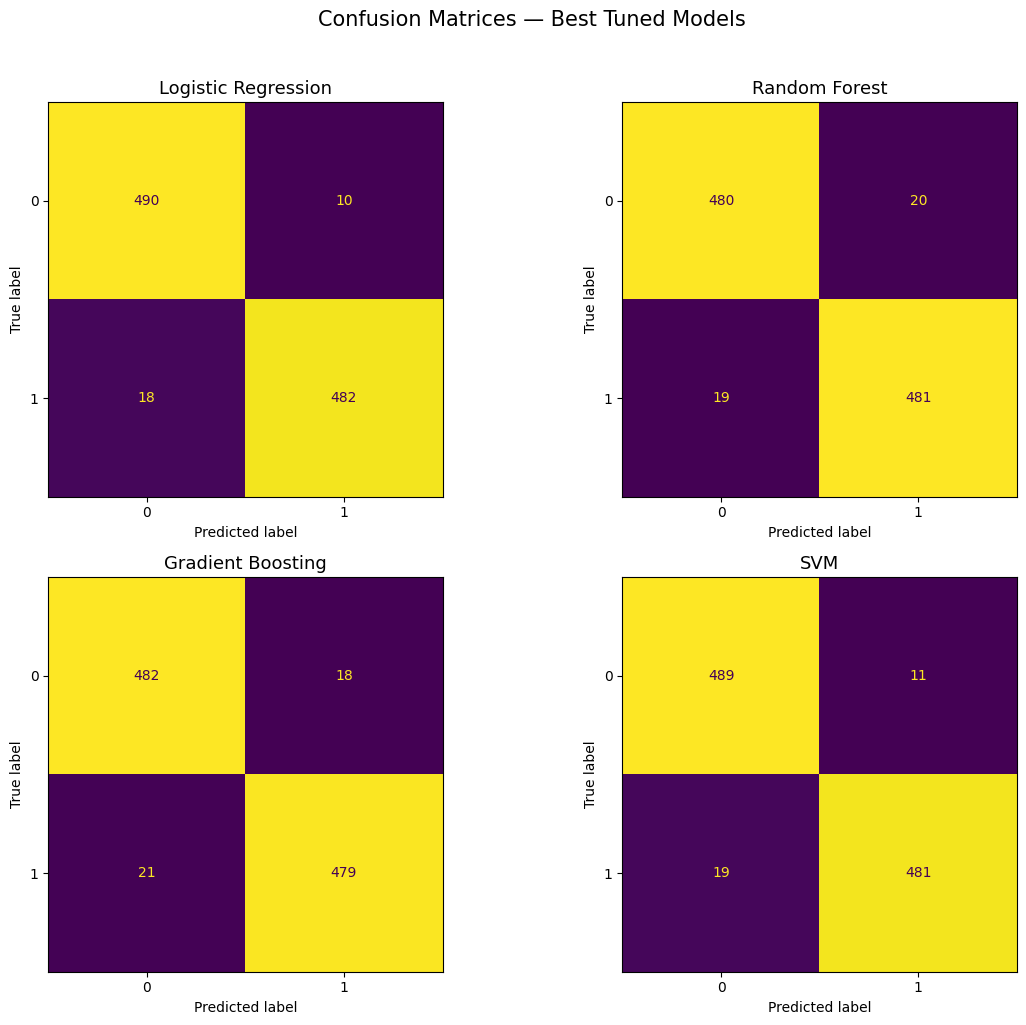

In [28]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Step 1: Define base pipelines ---
pipeline_lr  = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])
pipeline_rf  = Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))])
pipeline_gb  = Pipeline([('scaler', StandardScaler()), ('clf', GradientBoostingClassifier(random_state=42))])
pipeline_svm = Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42, class_weight='balanced'))])

# --- Step 2: Tune each model with its own param grid ---
rf_params = {
    'clf__n_estimators':    [50, 100, 200],
    'clf__max_depth':       [5, 10, 15, None],
    'clf__max_leaf_nodes':  [20, 50, 100, None],
    'clf__min_samples_leaf':[5, 10, 20],
}

gb_params = {
    'clf__n_estimators':    [50, 100, 200],
    'clf__max_depth':       [3, 5, 10],
    'clf__learning_rate':   [0.01, 0.05, 0.1],
    'clf__min_samples_leaf':[5, 10, 20],
}

lr_params = {
    'clf__C':       [0.01, 0.1, 1, 10],    # regularization strength
    'clf__penalty': ['l1', 'l2'],
    'clf__solver':  ['liblinear'],          # needed for l1
}

svm_params = {
    'clf__C':      [0.1, 1, 10],
    'clf__kernel': ['rbf', 'linear'],
    'clf__gamma':  ['scale', 'auto'],
}

searches = {
    'Logistic Regression': RandomizedSearchCV(pipeline_lr,  lr_params,  cv=cv, scoring='roc_auc', n_iter=10, random_state=42),
    'Random Forest':       RandomizedSearchCV(pipeline_rf,  rf_params,  cv=cv, scoring='roc_auc', n_iter=20, random_state=42),
    'Gradient Boosting':   RandomizedSearchCV(pipeline_gb,  gb_params,  cv=cv, scoring='roc_auc', n_iter=20, random_state=42),
    'SVM':                 RandomizedSearchCV(pipeline_svm, svm_params, cv=cv, scoring='roc_auc', n_iter=10, random_state=42),
}

# Fit all searches and collect best params
for name, search in searches.items():
    search.fit(X, y)
    print(f"{name} best params: {search.best_params_}")

# --- Step 3: Compare best versions of each model ---
results = {}
for name, search in searches.items():
    best_pipeline = search.best_estimator_   # ← tuned pipeline, not the original
    scores = cross_validate(best_pipeline, X, y, cv=cv,
                            scoring=['accuracy', 'f1', 'roc_auc'])
    results[name] = {
        'Accuracy': scores['test_accuracy'].mean().round(3),
        'F1':       scores['test_f1'].mean().round(3),
        'ROC-AUC':  scores['test_roc_auc'].mean().round(3),
    }

results_df = pd.DataFrame(results).T
print(results_df.sort_values('ROC-AUC', ascending=False))

# --- Step 4: Confusion matrix + Classification report for each best model ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, search) in enumerate(searches.items()):
    best_pipeline = search.best_estimator_

    # Get predictions across all folds
    y_pred = cross_val_predict(best_pipeline, X, y, cv=cv)

    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)#, display_labels=['No Conversion', 'Conversion'])
    disp.plot(ax=axes[idx], colorbar=False)
    axes[idx].set_title(f"{name}", fontsize=13)

    # Classification report printed below each matrix
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y, y_pred))#, target_names=['No Conversion', 'Conversion']))

plt.suptitle('Confusion Matrices — Best Tuned Models', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [29]:
import numpy as np

# Example: a new user you want to score
new_user = pd.DataFrame([{
    'Daily Time Spent on Site': 75.0,   # minutes on site
    'Age': 32,
    'Area Income': 65000,
    'Daily Internet Usage': 210.0,
    'Hour': 14,                          # 2pm
    'DayOfWeek': 1,                      # Tuesday
    'Month': 6,
    'Male': 1
}])

# Use best model (Logistic Regression)
best_model = searches['Logistic Regression'].best_estimator_

prediction    = best_model.predict(new_user)[0]
probability   = best_model.predict_proba(new_user)[0][1]

print(f"Predicted:   {'Clicked ✓' if prediction == 1 else 'Not Clicked ✗'}")
print(f"Probability of clicking: {probability:.1%}")

Predicted:   Not Clicked ✗
Probability of clicking: 1.4%


Heavy internet user are ad blind

In [38]:
new_user = pd.DataFrame([{
    'Daily Time Spent on Site': 70.0,   # lower time = more likely to click
    'Age': 45,                           # older users click more in this dataset
    'Area Income': 45000,                # lower income = more receptive
    'Daily Internet Usage': 180.0,       # lower usage = more receptive
    'Hour': 9,
    'DayOfWeek': 2,
    'Month': 3,
    'Male': 0
}])

# Use best model (Logistic Regression)
best_model = searches['Logistic Regression'].best_estimator_

prediction    = best_model.predict(new_user)[0]
probability   = best_model.predict_proba(new_user)[0][1]

print(f"Predicted:   {'Clicked ✓' if prediction == 1 else 'Not Clicked ✗'}")
print(f"Probability of clicking: {probability:.1%}")

Predicted:   Clicked ✓
Probability of clicking: 96.7%


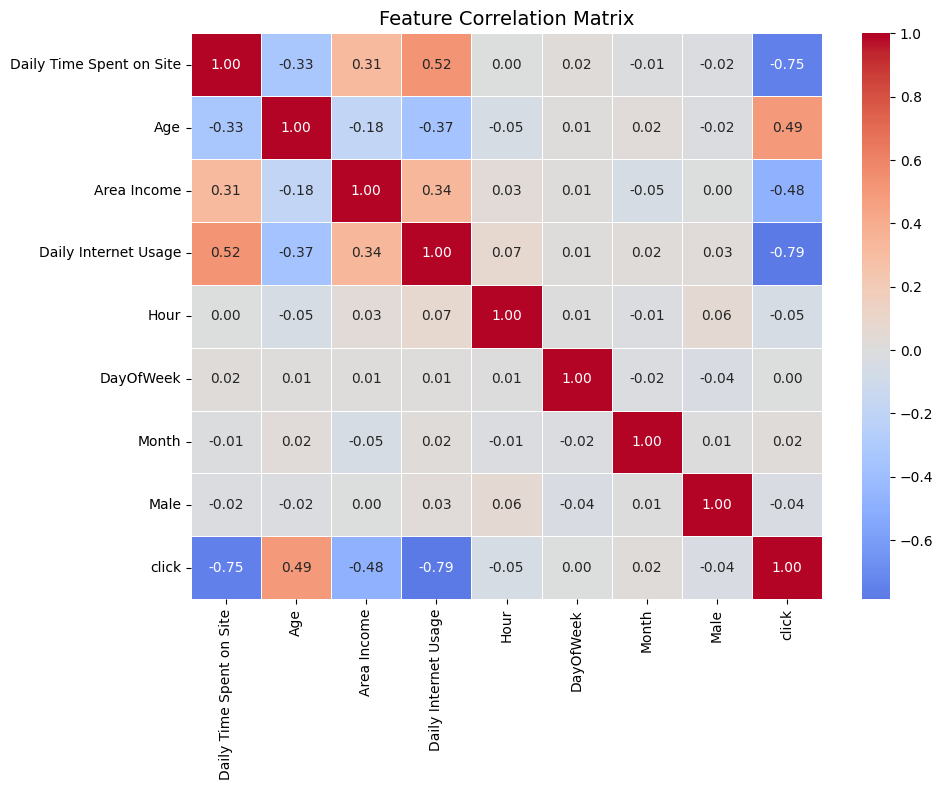

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = data[feature_cols + ['click']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [32]:
from scipy.stats import pointbiserialr

print("Correlation with 'Clicked on Ad':\n")
for col in feature_cols:
    corr, pval = pointbiserialr(data['click'], data[col])
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    print(f"  {col:<30} r = {corr:+.3f}   p = {pval:.4f}  {sig}")

Correlation with 'Clicked on Ad':

  Daily Time Spent on Site       r = -0.748   p = 0.0000  ***
  Age                            r = +0.493   p = 0.0000  ***
  Area Income                    r = -0.476   p = 0.0000  ***
  Daily Internet Usage           r = -0.787   p = 0.0000  ***
  Hour                           r = -0.047   p = 0.1339  ns
  DayOfWeek                      r = +0.002   p = 0.9496  ns
  Month                          r = +0.016   p = 0.6112  ns
  Male                           r = -0.038   p = 0.2296  ns


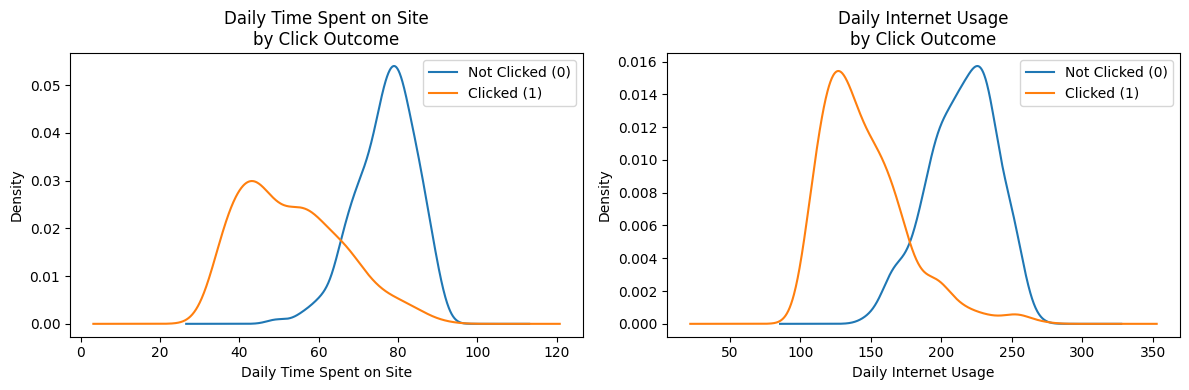

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['Daily Time Spent on Site', 'Daily Internet Usage']):
    data.groupby('click')[col].plot.kde(ax=ax, legend=True)
    ax.set_title(f'{col}\nby Click Outcome')
    ax.legend(['Not Clicked (0)', 'Clicked (1)'])
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

The negative correlation between time-on-site and clicking indicates that users who spend a lot of time on the site are likely already engaged with content and ignore ads, while users who land, don't find what they want, and bounce are more receptive to clicking out via an ad